<a href="https://colab.research.google.com/github/abhijithgithub23/ML-Model_Diabetes-Prediction/blob/main/Week10_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Define the column names
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']

#  Load the dataset directly from a URL
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
df = pd.read_csv(url, names=column_names)

#  first 5 rows to make sure it worked
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# 1. Identify columns where a value of 0 is medically impossible
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 2. Replace the 0s with NaN (Not a Number) so Python knows it's missing data
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

# 3. Fill those missing NaN values with the median of their respective columns
df.fillna(df.median(), inplace=True)

print("Zeroes fixed! Check the minimum values below to confirm:")
# df.describe() gives us a statistical summary of our data
df.describe()

Zeroes fixed! Check the minimum values below to confirm:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


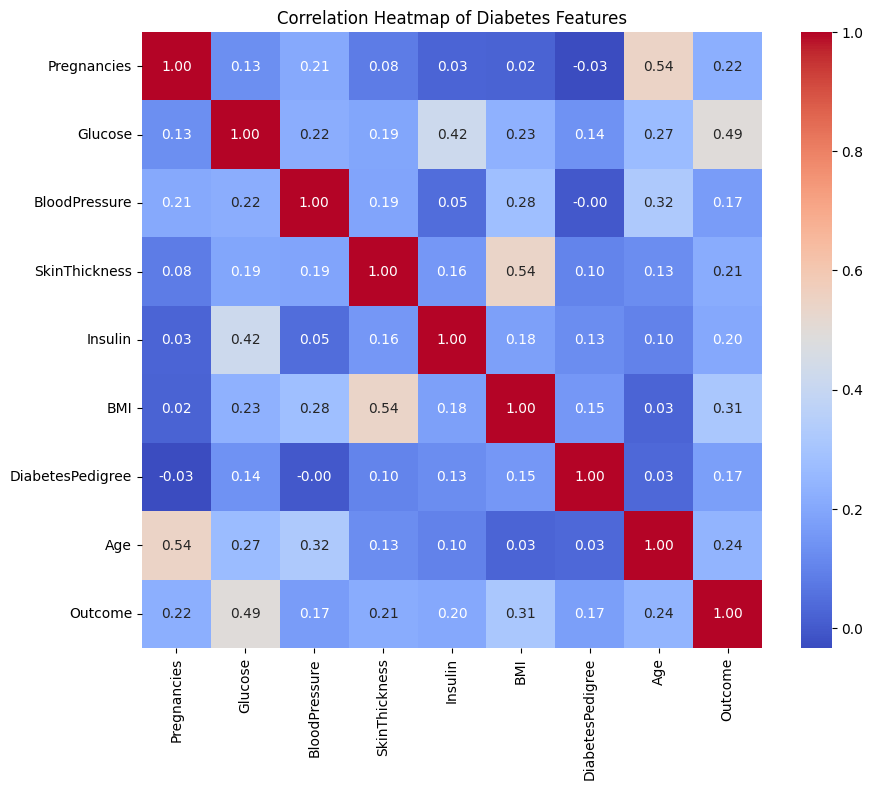

In [4]:
# Set the size of the graph
plt.figure(figsize=(10, 8))

# Create a heatmap of the correlations
# annot=True puts the numbers in the boxes, cmap sets the color theme
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap of Diabetes Features")
plt.show()

/tmp/ipykernel_13367/1974655356.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='Set2')


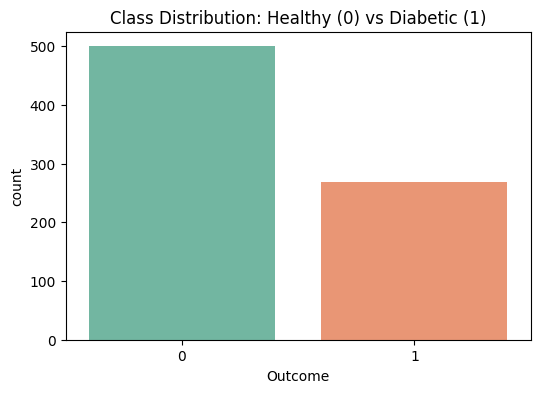

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title("Class Distribution: Healthy (0) vs Diabetic (1)")
plt.show()


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Separate Features (X) and Target (y)
X = df.drop('Outcome', axis=1) # Everything EXCEPT the outcome
y = df['Outcome']              # ONLY the outcome

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the features (Leveling the playing field)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Initialize the models
log_reg = LogisticRegression(random_state=42)
rf_model = RandomForestClassifier(random_state=42)

# 5. Train (fit) the models using our scaled training data
log_reg.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)

print("Models trained ")

Models trained 


In [7]:
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix

# make predictions
log_preds = log_reg.predict(X_test_scaled)
rf_preds = rf_model.predict(X_test_scaled)

# 2. Score the Logistic Regression model
print("=== LOGISTIC REGRESSION ===")
print(f"Accuracy: {accuracy_score(y_test, log_preds):.2f}")
print(f"Recall:   {recall_score(y_test, log_preds):.2f}")
print("\nClassification Report:\n", classification_report(y_test, log_preds))

# 3. Score the Random Forest model
print("\n=== RANDOM FOREST ===")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.2f}")
print(f"Recall:   {recall_score(y_test, rf_preds):.2f}")
print("\nClassification Report:\n", classification_report(y_test, rf_preds))

=== LOGISTIC REGRESSION ===
Accuracy: 0.75
Recall:   0.62

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154


=== RANDOM FOREST ===
Accuracy: 0.73
Recall:   0.64

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.79      0.79        99
           1       0.62      0.64      0.63        55

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



In [8]:
# ---  UPGRADED PIPELINE ---

# 1. The Stratified Split (Keeps the ratios perfectly balanced)
X_train_up, X_test_up, y_train_up, y_test_up = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Scale the data again
scaler_up = StandardScaler()
X_train_scaled_up = scaler_up.fit_transform(X_train_up)
X_test_scaled_up = scaler_up.transform(X_test_up)

# 3. The "Balanced" Random Forest (Forces it to care more about the diabetic patients)
rf_model_up = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model_up.fit(X_train_scaled_up, y_train_up)

# 4. Take the final exam again
rf_preds_up = rf_model_up.predict(X_test_scaled_up)

# 5. Print the new scores
print("=== UPGRADED RANDOM FOREST ===")
print(f"Accuracy: {accuracy_score(y_test_up, rf_preds_up):.2f}")
print(f"Recall:   {recall_score(y_test_up, rf_preds_up):.2f}")
print("\nClassification Report:\n", classification_report(y_test_up, rf_preds_up))

=== UPGRADED RANDOM FOREST ===
Accuracy: 0.74
Recall:   0.57

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.83      0.81       100
           1       0.65      0.57      0.61        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.71       154
weighted avg       0.73      0.74      0.74       154



In [9]:
# 1. Get the raw probabilities instead of the final Yes/No predictions
# This returns an array where the second column is the % chance of having diabetes
probabilities = rf_model_up.predict_proba(X_test_scaled_up)[:, 1]

# 2. Set our custom medical threshold (e.g., 35% instead of 50%)
custom_threshold = 0.35

# 3. Create new predictions: If probability > 35%, predict 1, else 0
custom_preds = (probabilities >= custom_threshold).astype(int)

# 4. Score the new threshold
print(f"=== CUSTOM THRESHOLD (>{int(custom_threshold*100)}%) ===")
print(f"Accuracy: {accuracy_score(y_test_up, custom_preds):.2f}")
print(f"Recall:   {recall_score(y_test_up, custom_preds):.2f}")
print("\nClassification Report:\n", classification_report(y_test_up, custom_preds))


=== CUSTOM THRESHOLD (>35%) ===
Accuracy: 0.73
Recall:   0.72

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.74      0.78       100
           1       0.60      0.72      0.66        54

    accuracy                           0.73       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



In [15]:
from sklearn.model_selection import GridSearchCV

# 1. Define the "Grid" of settings for the Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],     # How many trees in the forest?
    'max_depth': [5, 10, None],          # How deep can each tree grow? None = infinite
    'min_samples_leaf': [1, 2, 4],       # Minimum patients required at the end of a branch
}

# 2. Set up the Grid Search (Optimizing for Recall!)
rf_grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    rf_param_grid,
    cv=5,               # 5-Fold Cross Validation
    scoring='recall',   # Tell the model our main goal is finding sick patients
    n_jobs=-1           # Use all available computer power
)

# 3. Run the search
print("Planting hundreds of experimental forests... Please wait...")
rf_grid_search.fit(X_train_scaled_up, y_train_up)

# 4. Print the winning settings
print("\n=== BEST RANDOM FOREST SETTINGS ===")
print(rf_grid_search.best_params_)

# 5. Extract the champion model
best_rf_model = rf_grid_search.best_estimator_

# 6. Test the champion model with your custom 35% threshold
rf_tuned_probs = best_rf_model.predict_proba(X_test_scaled_up)[:, 1]
rf_tuned_preds = (rf_tuned_probs >= 0.35).astype(int)

# 7. Print the final results
print("\n=== FULLY OPTIMIZED RANDOM FOREST (>35% THRESHOLD) ===")
print(f"Accuracy: {accuracy_score(y_test_up, rf_tuned_preds):.2f}")
print(f"Recall:   {recall_score(y_test_up, rf_tuned_preds):.2f}")
print("\nClassification Report:\n", classification_report(y_test_up, rf_tuned_preds))

Planting hundreds of experimental forests... Please wait...

=== BEST RANDOM FOREST SETTINGS ===
{'max_depth': 5, 'min_samples_leaf': 2, 'n_estimators': 300}

=== FULLY OPTIMIZED RANDOM FOREST (>35% THRESHOLD) ===
Accuracy: 0.69
Recall:   0.87

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.60      0.72       100
           1       0.54      0.87      0.67        54

    accuracy                           0.69       154
   macro avg       0.72      0.74      0.69       154
weighted avg       0.77      0.69      0.70       154



In [11]:
# 1. Initialize Logistic Regression with 'balanced' class weights
log_reg_up = LogisticRegression(random_state=42, class_weight='balanced')

# 2. Train the model using our upgraded, stratified data
log_reg_up.fit(X_train_scaled_up, y_train_up)

# 3. Get the raw probabilities instead of the default Yes/No
log_probabilities = log_reg_up.predict_proba(X_test_scaled_up)[:, 1]

# 4. Apply our custom 35% medical threshold
custom_threshold = 0.35
log_custom_preds = (log_probabilities >= custom_threshold).astype(int)

# 5. Print the new final scores
print(f"=== UPGRADED LOGISTIC REGRESSION (>{int(custom_threshold*100)}% THRESHOLD) ===")
print(f"Accuracy: {accuracy_score(y_test_up, log_custom_preds):.2f}")
print(f"Recall:   {recall_score(y_test_up, log_custom_preds):.2f}")
print("\nClassification Report:\n", classification_report(y_test_up, log_custom_preds))

=== UPGRADED LOGISTIC REGRESSION (>35% THRESHOLD) ===
Accuracy: 0.73
Recall:   0.89

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.64      0.75       100
           1       0.57      0.89      0.70        54

    accuracy                           0.73       154
   macro avg       0.74      0.76      0.72       154
weighted avg       0.79      0.73      0.73       154



In [18]:
# 1. Create a copy of our original data
df_pro = df.copy()

# 2. FEATURE ENGINEERING: Create our new "Super Features"
# Combining Glucose and BMI into a single compounding risk score
df_pro['Glucose_BMI_Risk'] = df_pro['Glucose'] * df_pro['BMI']

# Combining Age and Pregnancies
df_pro['Age_Pregnancies_Risk'] = df_pro['Age'] * df_pro['Pregnancies']

# 3. Separate the new Features (X) and Target (y)
X_pro = df_pro.drop('Outcome', axis=1)
y_pro = df_pro['Outcome']

# 4. Re-Split the data (keeping the stratified upgrade)
X_train_pro, X_test_pro, y_train_pro, y_test_pro = train_test_split(
    X_pro, y_pro, test_size=0.2, random_state=42, stratify=y_pro
)

# 5. Re-Scale the new data
scaler_pro = StandardScaler()
X_train_scaled_pro = scaler_pro.fit_transform(X_train_pro)
X_test_scaled_pro = scaler_pro.transform(X_test_pro)

# 6. Run your EXACT SAME winning model
log_reg_pro = LogisticRegression(random_state=42, class_weight='balanced')
log_reg_pro.fit(X_train_scaled_pro, y_train_pro)

# 7. Apply your 35% custom threshold
pro_probs = log_reg_pro.predict_proba(X_test_scaled_pro)[:, 1]
pro_preds = (pro_probs >= 0.35).astype(int)

# 8. Print the final scores
print(f"=== FEATURE ENGINEERED LOGISTIC REGRESSION (>35% THRESHOLD) ===")
print(f"Accuracy: {accuracy_score(y_test_pro, pro_preds):.2f}")
print(f"Recall:   {recall_score(y_test_pro, pro_preds):.2f}")
print("\nClassification Report:\n", classification_report(y_test_pro, pro_preds))

=== FEATURE ENGINEERED LOGISTIC REGRESSION (>35% THRESHOLD) ===
Accuracy: 0.74
Recall:   0.89

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.66      0.77       100
           1       0.59      0.89      0.71        54

    accuracy                           0.74       154
   macro avg       0.75      0.77      0.74       154
weighted avg       0.80      0.74      0.75       154



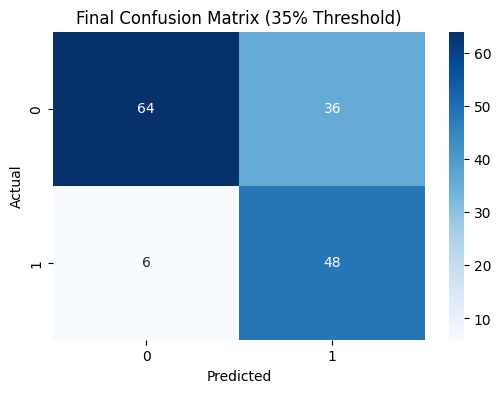

In [24]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_up, log_custom_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Confusion Matrix (35% Threshold)")
plt.show()

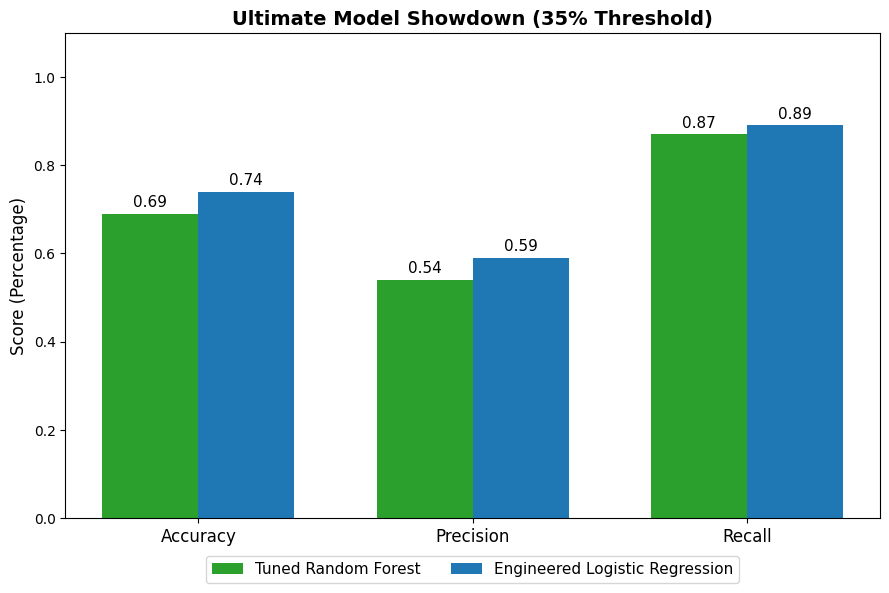

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define our final models and their absolute best scores
labels = ['Accuracy', 'Precision', 'Recall']

# Scores from your GridSearchCV Random Forest
rf_scores = [0.69, 0.54, 0.87]

# Scores from your Feature Engineered Logistic Regression
log_scores = [0.74, 0.59, 0.89]

x = np.arange(len(labels))  # The label locations
width = 0.35                # The width of the bars

# 2. Set up the graph size and style
fig, ax = plt.subplots(figsize=(9, 6))

# 3. Create the bars
rects1 = ax.bar(x - width/2, rf_scores, width, label='Tuned Random Forest', color='#2ca02c')
rects2 = ax.bar(x + width/2, log_scores, width, label='Engineered Logistic Regression', color='#1f77b4')

# 4. Add labels, title, and formatting
ax.set_ylabel('Score (Percentage)', fontsize=12)
ax.set_title('Ultimate Model Showdown (35% Threshold)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 1.1)

# Move the legend out of the way of the bars
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=11)

# 5. Add the exact numbers on top of the bars for easy reading
ax.bar_label(rects1, padding=3, fontsize=11, fmt='%.2f')
ax.bar_label(rects2, padding=3, fontsize=11, fmt='%.2f')

# 6. Display the graph
plt.tight_layout()
plt.show()

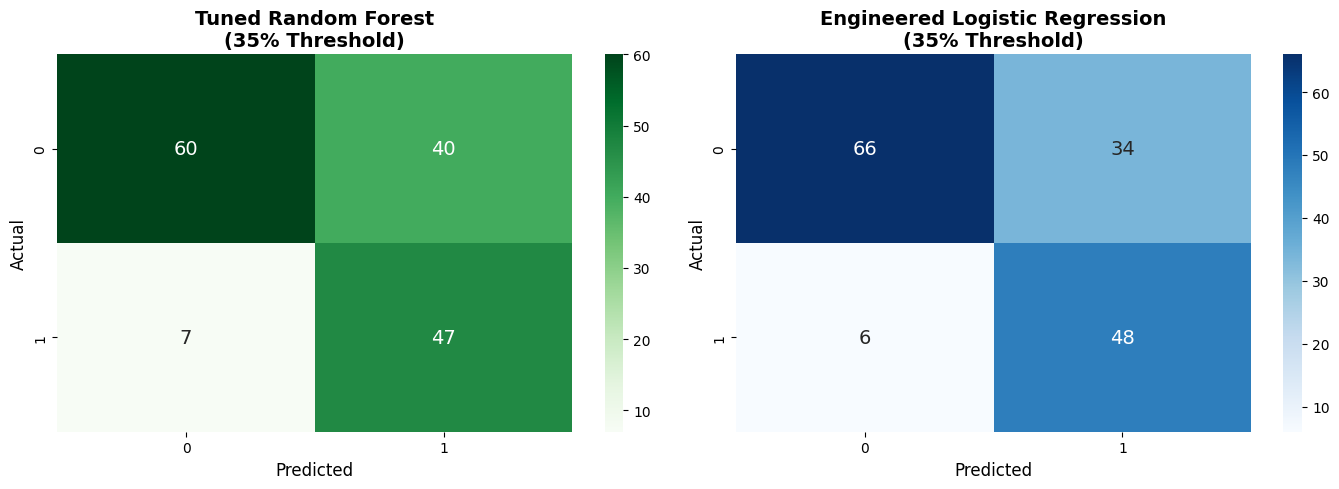

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Calculate the matrices using the correct true labels and predictions
cm_rf = confusion_matrix(y_test_up, rf_tuned_preds)
cm_log = confusion_matrix(y_test_pro, pro_preds)

# 2. Set up a side-by-side figure (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 3. Plot Dr. Forest's Matrix (Left Side)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            annot_kws={"size": 14}) # Makes the numbers larger
axes[0].set_title('Tuned Random Forest\n(35% Threshold)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)

# 4. Plot Dr. Logistic's Matrix (Right Side)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            annot_kws={"size": 14})
axes[1].set_title('Engineered Logistic Regression\n(35% Threshold)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)

# 5. Display the beautiful comparison
plt.tight_layout()
plt.show()

In [30]:
import pandas as pd

# 1. Input the new patient's raw medical data
new_patient_data = {
    'Pregnancies': [1],
    'Glucose': [92],
    'BloodPressure': [72],
    'SkinThickness': [20],
    'Insulin': [85],
    'BMI': [22.4],
    'DiabetesPedigree': [0.18],
    'Age': [24]
}

new_patient_df = pd.DataFrame(new_patient_data)

# ==========================================
# PIPELINE 1: RANDOM FOREST (8 Features)
# ==========================================
# Scale using the original scaler
new_patient_scaled_rf = scaler_up.transform(new_patient_df)

# Predict using the Tuned Random Forest
rf_probability = best_rf_model.predict_proba(new_patient_scaled_rf)[0, 1]


# ==========================================
# PIPELINE 2: LOGISTIC REGRESSION (10 Features)
# ==========================================
# Create the "Super Features" on the fly for the new patient!
new_patient_pro_df = new_patient_df.copy()
new_patient_pro_df['Glucose_BMI_Risk'] = new_patient_pro_df['Glucose'] * new_patient_pro_df['BMI']
new_patient_pro_df['Age_Pregnancies_Risk'] = new_patient_pro_df['Age'] * new_patient_pro_df['Pregnancies']

# Scale using the NEW scaler
new_patient_scaled_lr = scaler_pro.transform(new_patient_pro_df)

# Predict using the Engineered Logistic Regression
lr_probability = log_reg_pro.predict_proba(new_patient_scaled_lr)[0, 1]


# ==========================================
# FINAL DIAGNOSTIC REPORT
# ==========================================
threshold = 0.35

rf_diagnosis = "DIABETES DETECTED (Flagged)" if rf_probability >= threshold else "HEALTHY (Cleared)"
lr_diagnosis = "DIABETES DETECTED (Flagged)" if lr_probability >= threshold else "HEALTHY (Cleared)"

print("========================================")
print("      MULTI-MODEL DIAGNOSTIC REPORT     ")
print("========================================")
print("----------------------------------------")
print("RANDOM FOREST (Optimized):")
print(f"   Calculated Probability: {rf_probability * 100:.1f}%")
print(f"   Final Decision:         {rf_diagnosis}")
print("----------------------------------------")
print("LOGISTIC REGRESSION (Engineered):")
print(f"   Calculated Probability: {lr_probability * 100:.1f}%")
print(f"   Final Decision:         {lr_diagnosis}")
print("========================================")
print(f"*Diagnostic Threshold strictly enforced at {threshold * 100:.0f}%")

      MULTI-MODEL DIAGNOSTIC REPORT     
----------------------------------------
RANDOM FOREST (Optimized):
   Calculated Probability: 2.8%
   Final Decision:         HEALTHY (Cleared)
----------------------------------------
LOGISTIC REGRESSION (Engineered):
   Calculated Probability: 3.7%
   Final Decision:         HEALTHY (Cleared)
*Diagnostic Threshold strictly enforced at 35%
